# Multiple Linear Regression - ML Approach
# Demonstration In Python
#### Using Motor Claims Data

## Background 

 A motor insurance company routinely collects detailed vehicle and policyholder information at the time of issuing and processing insurance claims. The pricing analytics team periodically analyzes this data to identify risk drivers and determine whether vehicle attributes can be used to model and predict claim severity. The dataset used in this study consists of policyholders from urban locations and includes claims for similar motor insurance products, ensuring consistency in risk exposure and coverage terms.

## Objective

To develop a predictive model that estimates motor insurance claim amount based on specific vehicle-related characteristics recorded during policy registration and claim processing. The insights are expected to support pricing accuracy, risk segmentation, and underwriting decisions.

 
**Data Specifications**

 Sample Size:1,000 motor insurance claim records

Geographical Scope:Urban region customers only

Product Type:Similar motor insurance coverage plan across all records

Observation Type: Individual claim cases

Data Source: Internal structured claim and registration database


## Data Description :

| Columns   | Description                                 | Type     | Measurement |
|-----------|----------------------------------------------|----------|-------------|
| vehage    | Age of the vehicle at the time of claim      | integer  | Years       |
| CC        | Engine capacity                              | numeric  | cc          |
| Length    | Length of the vehicle                        | numeric  | mm          |
| Weight    | Weight of the vehicle                        | numeric  | kg          |
| claimamt  | Claim amount                                 | numeric  | INR         |


### 1. Import Libraries 

**Scikit-learn (sklearn)** is a powerful Python machine learning library that provides easy-to-use tools for data preprocessing, modeling, evaluation, and deployment. It includes a wide range of algorithms for classification, regression, clustering, and dimensionality reduction. Its simple and consistent API makes it ideal for building and comparing ML models efficiently.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split,KFold,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')


### 2.  Import Data

In [2]:
df = pd.read_csv('Motor_Claims.csv')
df.head()

,vehage,CC,Length,Weight,claimamt
0,4,1495,4250,1023,72000.0
1,2,1061,3495,875,72000.0
2,2,1405,3675,980,50400.0
3,7,1298,4090,930,39960.0
4,2,1495,4250,1023,106800.0


In [3]:
df.dtypes

vehage        int64
CC            int64
Length        int64
Weight        int64
claimamt    float64
dtype: object

### 3. Perform Feature Engineering

Here, we will create 2 new features: cc/weight and length/weight

In [4]:
# Create features
df['CC_per_Weight'] = df['CC'] / df['Weight']
df['Length_per_Weight'] = df['Length'] / df['Weight']

### 4. Correlation Analysis Using Heatmap


We will explore the dataset by visualizing the relationships between all the variables to understand patterns, correlations.


In [5]:
#Compute correlation matrix
corr_matrix = df.corr()
print("Correlation Matrix:")
corr_matrix

Correlation Matrix:


,vehage,CC,Length,Weight,claimamt,CC_per_Weight,Length_per_Weight
vehage,1.000000,0.128200,0.188211,0.140256,-0.600969,0.029022,-0.087312
CC,0.128200,1.000000,0.804101,0.905569,0.458095,0.688001,-0.872729
Length,0.188211,0.804101,1.000000,0.826465,0.478082,0.424105,-0.660287
Weight,0.140256,0.905569,0.826465,1.000000,0.416987,0.339949,-0.926625
claimamt,-0.600969,0.458095,0.478082,0.416987,1.000000,0.347549,-0.417763
CC_per_Weight,0.029022,0.688001,0.424105,0.339949,0.347549,1.000000,-0.410069
Length_per_Weight,-0.087312,-0.872729,-0.660287,-0.926625,-0.417763,-0.410069,1.000000


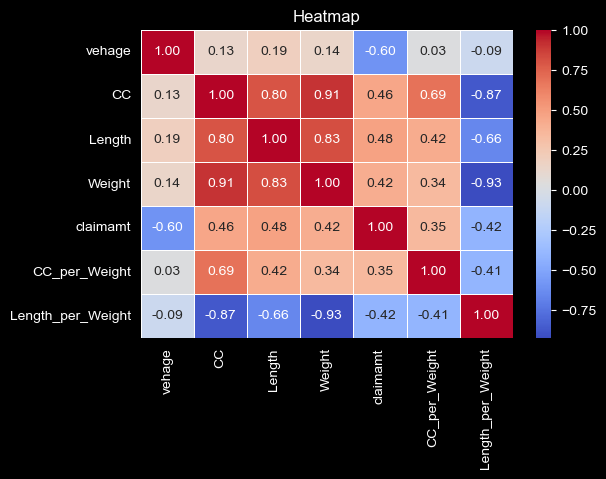

In [6]:
plt.figure(figsize=(6,4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Heatmap")
plt.show()

### 5.  Model A : Linear Regression With Original Vriables

### a. Check for Multicollinearity problem

In [7]:
y1, X1 = dmatrices('claimamt~vehage+CC+Length+Weight', data=df, return_type="dataframe")

vif = pd.Series([variance_inflation_factor(X1.values, i)for i in range(X1.shape[1])],index=X1.columns)
vif

Intercept    240.261728
vehage         1.038357
CC             5.881428
Length         3.396171
Weight         6.552811
dtype: float64

#### Since 2 VIF'S values are > 5, the multicollinearity problem exists. We will drop the variable 'Weight' and proceed

In [8]:
y1, X1 = dmatrices('claimamt~vehage+CC+Length', data=df, return_type="dataframe")

vif = pd.Series([variance_inflation_factor(X1.values, i)for i in range(X1.shape[1])],index=X1.columns)
vif

Intercept    227.959103
vehage         1.038355
CC             2.833931
Length         2.889718
dtype: float64

#### Since all VIF's are <5, the multicollinearity problem is resolved

### b. Split Data Into Train & Test

In [9]:
X = df.drop(columns=['claimamt'])
y = df['claimamt']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)


# Display shapes
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (700, 6)
Testing Data Shape: (300, 6)


In [10]:
# Creating vector of features
model_A_vars = ['vehage', 'CC', 'Length'] #Removing Weight due to multicollinearity

In [11]:
X_train_A = X_train[model_A_vars]
X_test_A  = X_test[model_A_vars]

### c. Build Model


In [12]:
linreg = LinearRegression()

linreg.fit(X_train_A,y_train)

LinearRegression()

#### Display Model Coefficients

In [13]:
coeff_df = pd.DataFrame({
    'Feature': X_train_A.columns,
    'Coefficient': linreg.coef_
})

coeff_df

,Feature,Coefficient
0,vehage,-6589.815924
1,CC,8.488830
2,Length,33.420047


### d. Model Evaluation - R² And RMSE

In [14]:
# Predictions
y_train_pred = linreg.predict(X_train_A)
y_test_pred = linreg.predict(X_test_A)

R² & RMSE For Train

In [15]:
r2_train = r2_score(y_train, y_train_pred)
rmse_train = mean_squared_error(y_train, y_train_pred, squared=False)

print("TRAIN Performance:")
print("R² (Train):", r2_train)
print("RMSE (Train):", rmse_train)

TRAIN Performance:
R² (Train): 0.7542791664783428
RMSE (Train): 11052.116461552378


R² & RMSE For Test

In [16]:
r2_test = r2_score(y_test, y_test_pred)
rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)

print("\nTEST Performance:")
print("R² (Test):", r2_test)
print("RMSE (Test):", rmse_test)


TEST Performance:
R² (Test): 0.6785108832296907
RMSE (Test): 12340.329382947331


#### The RMSE for test data is higher than RMSE for train data

### 6. Model B :  Linear Regression With Original & Derived Variables


### a. Check for  Multicollinearity problem

In [17]:
y1, X1 = dmatrices('claimamt~vehage+CC+Length+Weight+CC_per_Weight+Length_per_Weight', data=df, return_type="dataframe")

vif = pd.Series([variance_inflation_factor(X1.values, i)for i in range(X1.shape[1])],index=X1.columns)
vif

Intercept            2345.061403
vehage                  1.048768
CC                     65.848091
Length                  5.861126
Weight                 76.488791
CC_per_Weight          15.174816
Length_per_Weight      13.213040
dtype: float64

#### The VIF values for 'CC' and 'Weight' are very high, therefore, we exclude these variable and retain only derived variables along with 'vehage' and 'length'

In [18]:
y1, X1 = dmatrices('claimamt~vehage+Length+CC_per_Weight+Length_per_Weight', data=df, return_type="dataframe")

vif = pd.Series([variance_inflation_factor(X1.values, i)for i in range(X1.shape[1])],index=X1.columns)
vif

Intercept            567.178291
vehage                 1.041784
Length                 1.929586
CC_per_Weight          1.268559
Length_per_Weight      1.843203
dtype: float64

### b. Build The Model 

In [19]:
# Creating vector of features
model_B_vars = ['vehage',  'Length', 'CC_per_Weight','Length_per_Weight']

In [20]:
X_train_B = X_train[model_B_vars]
X_test_B  = X_test[model_B_vars]


In [21]:
# Create model object
linreg2 = LinearRegression()

# Fit model on updated training data
linreg2.fit(X_train_B, y_train)

LinearRegression()

#### Display Model Coefficients

In [22]:
coeff_df = pd.DataFrame({
    'Feature': X_train_B.columns,
    'Coefficient': linreg2.coef_
})

coeff_df

,Feature,Coefficient
0,vehage,-6544.302403
1,Length,35.178308
2,CC_per_Weight,17746.717949
3,Length_per_Weight,-2948.489225


### c. Model Evaluation - R² And RMSE

In [23]:
# Predictions
y_train_pred_b = linreg2.predict(X_train_B)
y_test_pred_b = linreg2.predict(X_test_B)

R² & RMSE For Train

In [24]:
r2_train = r2_score(y_train, y_train_pred_b)
rmse_train = mean_squared_error(y_train, y_train_pred_b, squared=False)

print("TRAIN Performance:")
print("R² (Train):", r2_train)
print("RMSE (Train):", rmse_train)

TRAIN Performance:
R² (Train): 0.7646624664689601
RMSE (Train): 10816.084249887184


R² & RMSE For Test

In [25]:
r2_test = r2_score(y_test, y_test_pred_b)
rmse_test = mean_squared_error(y_test, y_test_pred_b, squared=False)

print("\nTEST Performance:")
print("R² (Test):", r2_test)
print("RMSE (Test):", rmse_test)


TEST Performance:
R² (Test): 0.6899376551027084
RMSE (Test): 12119.037453851328


#### RMSE for Model B is lesser than that of Model A

### 7. K-Fold Cross Validation For Model B

In [26]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rmse = -cross_val_score(
    linreg2, X, y,
    scoring="neg_root_mean_squared_error",
    cv=kf
)

cv_rmse, cv_rmse.mean()


(array([11279.28800446, 12007.20103754,  9467.39423136, 10467.36272359,
        11039.36538642]),
 10852.122276673837)

### Inference :
The average RMSE is 10852 which is very close to training data (10816)